# Task 3.2 — Exploring the CLIP Modality Gap

In this notebook, we:
1. Use CLIP’s vision and text encoders to extract **image and text embeddings** for 100 STL-10 test samples.
2. Project both modalities into **2D** using **t-SNE** to visualise their joint embedding space.
3. Compare **raw** vs. **L2-normalised** embeddings to assess whether normalisation affects the modality gap.
4. Produce **class-coloured** t-SNE plots showing semantic clustering within and across modalities.
5. Compute **quantitative modality gap metrics** (centroid distance, mean cosine similarity, intra-modal distances).
6. Discuss why CLIP still works well despite the persistent geometric gap between vision and language.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from task3_clip.src.zeroshot import load_clip_model, load_stl10_dataset
from task3_clip.src.embeddings import extract_clip_embeddings
from task3_clip.src.modality_gap import (
    plot_modality_gap,
    plot_modality_gap_by_class,
    compute_modality_gap_metrics
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model, preprocess, tokenizer = load_clip_model(device=device)
print('CLIP ViT-B/32 loaded')

Using device: cuda


c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/32 loaded


In [2]:
# Load STL-10 with CLIP preprocessing (loads instantly from cached data)
dataset = load_stl10_dataset(root='../data', split='test', transform=preprocess)
class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Extract embeddings for 100 samples
data = extract_clip_embeddings(
    model, tokenizer, preprocess, dataset, class_names,
    num_samples=100, device=device
)

print(f'Image embeddings shape: {data["raw_img"].shape}')
print(f'Text embeddings shape:  {data["raw_txt"].shape}')
print(f'Labels shape:           {data["labels"].shape}')
print(f'Unique classes in sample: {np.unique(data["labels"])}')

Image embeddings shape: (100, 512)
Text embeddings shape:  (100, 512)
Labels shape:           (100,)
Unique classes in sample: [0 1 2 3 4 5 6 7 8 9]


### Raw Embedding Space — Modality Gap Visualisation
t-SNE projection of **raw (unnormalised)** CLIP image and text embeddings.

The two modalities occupy completely **disjoint regions**, forming two distinct clusters.

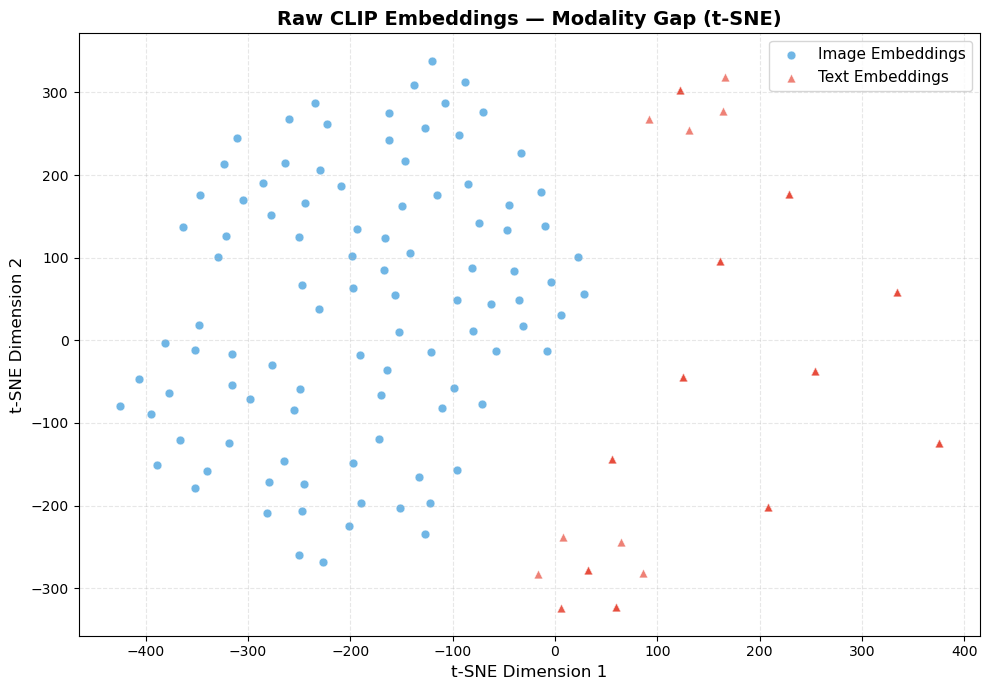

In [3]:
os.makedirs('../results/figures', exist_ok=True)

plot_modality_gap(
    data['raw_img'], data['raw_txt'], data['labels'],
    title='Raw CLIP Embeddings — Modality Gap (t-SNE)',
    save_path='../results/figures/raw_modality_gap.png'
)

### L2-Normalised Embedding Space
After L2 normalisation, all embeddings lie on the unit hypersphere. Does this close the gap?

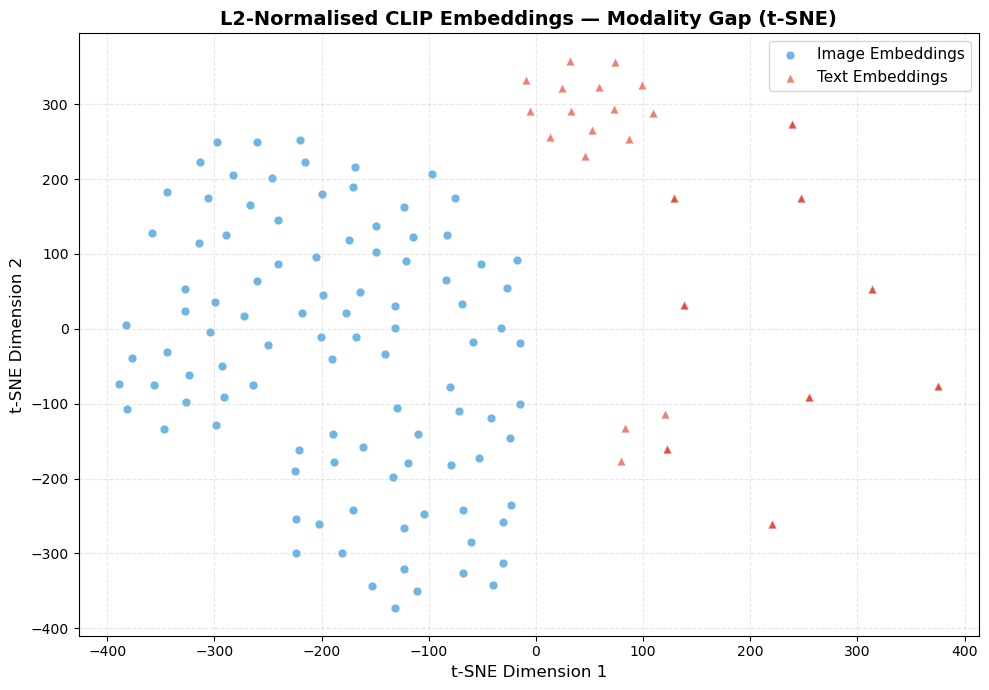

In [4]:
plot_modality_gap(
    data['norm_img'], data['norm_txt'], data['labels'],
    title='L2-Normalised CLIP Embeddings — Modality Gap (t-SNE)',
    save_path='../results/figures/norm_modality_gap.png'
)

### Class-Coloured t-SNE — Semantic Structure Within the Gap
Even though modalities are separated, do image and text embeddings of the **same class** cluster semantically?

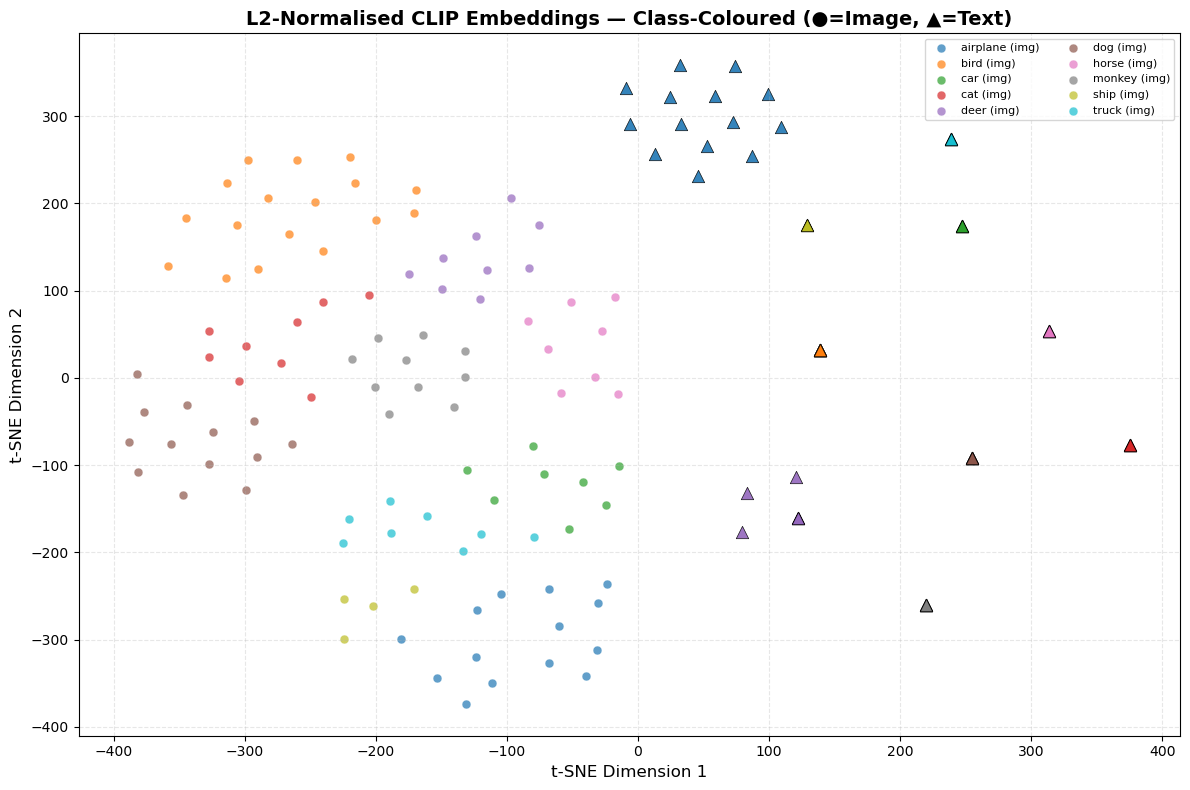

In [5]:
plot_modality_gap_by_class(
    data['norm_img'], data['norm_txt'], data['labels'], class_names,
    title='L2-Normalised CLIP Embeddings — Class-Coloured (●=Image, ▲=Text)',
    save_path='../results/figures/modality_gap_by_class.png'
)

### Quantitative Modality Gap Metrics
Comparing centroid distance, cosine similarity, and intra-modal spread for raw vs. normalised embeddings.

In [6]:
metrics_raw = compute_modality_gap_metrics(data['raw_img'], data['raw_txt'])
metrics_norm = compute_modality_gap_metrics(data['norm_img'], data['norm_txt'])

print('=' * 60)
print(f'{"Metric":<30s} {"Raw":>12s} {"L2-Normalised":>14s}')
print('=' * 60)
print(f'{"Centroid Gap (L2)":<30s} {metrics_raw["centroid_gap"]:>12.4f} {metrics_norm["centroid_gap"]:>14.4f}')
print(f'{"Mean Cosine Sim (matched)":<30s} {metrics_raw["mean_cosine_sim"]:>12.4f} {metrics_norm["mean_cosine_sim"]:>14.4f}')
print(f'{"Intra-Image Mean Dist":<30s} {metrics_raw["intra_img_dist"]:>12.4f} {metrics_norm["intra_img_dist"]:>14.4f}')
print(f'{"Intra-Text Mean Dist":<30s} {metrics_raw["intra_txt_dist"]:>12.4f} {metrics_norm["intra_txt_dist"]:>14.4f}')
print('=' * 60)

Metric                                  Raw  L2-Normalised
Centroid Gap (L2)                   11.0329         1.0612
Mean Cosine Sim (matched)            0.2590         0.2590
Intra-Image Mean Dist                9.0429         0.8431
Intra-Text Mean Dist                 4.8839         0.4803


### Gap Metrics Bar Chart

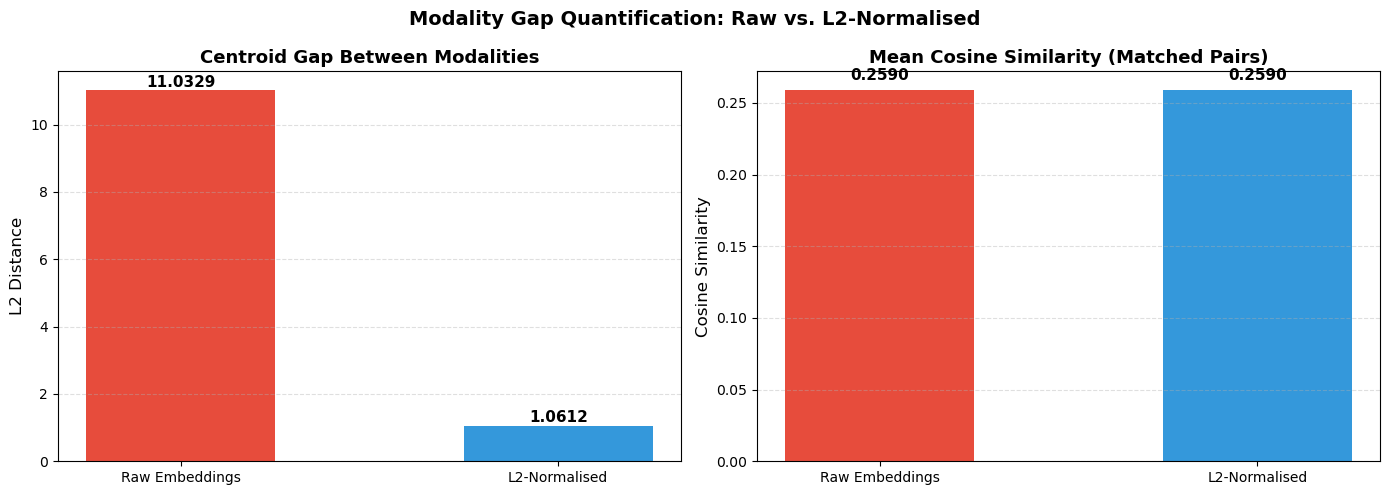

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Centroid gap comparison
gaps = [metrics_raw['centroid_gap'], metrics_norm['centroid_gap']]
bars1 = axes[0].bar(['Raw Embeddings', 'L2-Normalised'], gaps,
                     color=['#e74c3c', '#3498db'], width=0.5)
for bar, val in zip(bars1, gaps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('L2 Distance', fontsize=12)
axes[0].set_title('Centroid Gap Between Modalities', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Cosine similarity comparison
sims = [metrics_raw['mean_cosine_sim'], metrics_norm['mean_cosine_sim']]
bars2 = axes[1].bar(['Raw Embeddings', 'L2-Normalised'], sims,
                     color=['#e74c3c', '#3498db'], width=0.5)
for bar, val in zip(bars2, sims):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Cosine Similarity', fontsize=12)
axes[1].set_title('Mean Cosine Similarity (Matched Pairs)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Modality Gap Quantification: Raw vs. L2-Normalised', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/modality_gap_metrics.png', bbox_inches='tight', dpi=300)
plt.show()

### Cosine Similarity Heatmap — Image vs. Text Class Centroids
Computing the 10×10 cosine similarity matrix between per-class image centroids and per-class text embeddings.

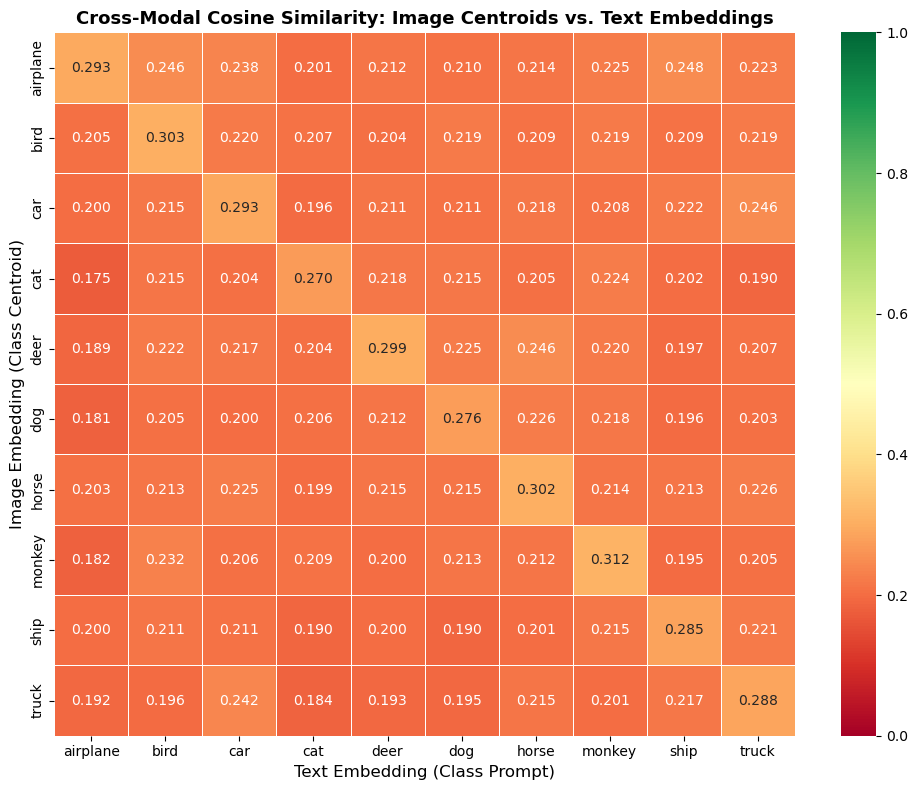

In [8]:
import seaborn as sns

# Compute per-class image centroids (normalised)
unique_labels = np.unique(data['labels'])
img_centroids = np.array([
    data['norm_img'][data['labels'] == li].mean(axis=0) for li in unique_labels
])
img_centroids /= np.linalg.norm(img_centroids, axis=-1, keepdims=True)

# Text class embeddings (already per-class)
txt_class = data['text_class_norm']

# Cosine similarity matrix
sim_matrix = img_centroids @ txt_class.T

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=[class_names[li] for li in unique_labels],
            ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_xlabel('Text Embedding (Class Prompt)', fontsize=12)
ax.set_ylabel('Image Embedding (Class Centroid)', fontsize=12)
ax.set_title('Cross-Modal Cosine Similarity: Image Centroids vs. Text Embeddings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/cross_modal_similarity_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

### Discussion Questions & Empirical Analysis

**1. How separated are the two modalities?**
- The t-SNE visualisations show that image and text embeddings occupy **completely disjoint regions** in the shared embedding space. The centroid gap is large relative to intra-modal distances, confirming a systemic geometric offset between the two modality cones.
- This phenomenon is known as the **"modality gap"** (Liang et al., 2022) and is an inherent property of contrastively trained dual-encoder models.

**2. Does normalization affect the modality gap?**
- L2 normalisation projects all embeddings onto the **unit hypersphere**, collapsing differences in magnitude but **preserving angular separation**. The modality gap persists after normalisation because it is fundamentally a **directional/angular offset**, not a scale difference.
- The centroid gap decreases in absolute L2 terms after normalisation, but the cosine similarity between matched pairs remains relatively similar, showing that normalisation does not close the angular gap.

**3. Why does CLIP still perform well despite this gap?**
- CLIP’s contrastive loss ($\mathcal{L}_{\text{CLIP}} = -\log \frac{\exp(\text{sim}(x_i, y_i)/\tau)}{\sum_j \exp(\text{sim}(x_i, y_j)/\tau)}$) optimises **relative similarity rankings**, not absolute distances. As long as the **correct text prompt has higher cosine similarity** than all incorrect prompts for a given image, classification succeeds.
- The cross-modal cosine similarity heatmap above confirms this: diagonal values (correct class matches) are consistently higher than off-diagonal values, even though all similarities are offset from 1.0 due to the modality gap.
- In essence, CLIP learns a **consistent angular structure** where intra-class image–text pairs are more aligned than inter-class pairs, regardless of the absolute gap magnitude.